<a href="https://colab.research.google.com/github/Ambika1704/Ensemble-learning/blob/main/ensemble_bank_marketing_fixed_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensemble Learning — Bank Marketing Subscription Prediction

**Dataset**: UCI Bank Marketing (`bank-full.csv`, semicolon-delimited)  
**Task**: Binary classification — will the client subscribe to a term deposit? (`y`: yes/no)  
**Ensemble methods covered**:
| Model | Type |
|---|---|
| Logistic Regression | Baseline (linear) |
| Random Forest | Bagging |
| Gradient Boosting (Tuned) | Boosting |
| Stacking Classifier | Stacking (meta-learner on OOF predictions) |
| Soft Voting Ensemble | Weighted probability averaging |

---
**Run cells top-to-bottom. The very first cell will prompt you to upload `bank-full.csv`.**

## Step 0 — Upload Dataset
Run this cell and use the file picker to upload `bank-full.csv`.

In [ ]:
from google.colab import files
import io, os

print("Please upload bank-full.csv ...")
uploaded = files.upload()

# Accept any filename the user uploaded and normalise it
uploaded_name = list(uploaded.keys())[0]
DATA_PATH = "bank-full.csv"

with open(DATA_PATH, "wb") as f:
    f.write(uploaded[uploaded_name])

print(f"\nSaved as '{DATA_PATH}' ({os.path.getsize(DATA_PATH):,} bytes)")

Please upload bank-full.csv ...


Saving bank-full.csv to bank-full.csv

Saved as 'bank-full.csv' (4,610,348 bytes)


## Step 1 — Install / verify dependencies

In [ ]:
# All libraries below are pre-installed on Colab; this cell just confirms versions.
import sklearn, pandas, numpy, matplotlib, seaborn
print(f"scikit-learn : {sklearn.__version__}")
print(f"pandas       : {pandas.__version__}")
print(f"numpy        : {numpy.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")
print(f"seaborn      : {seaborn.__version__}")

scikit-learn : 1.6.1
pandas       : 2.2.2
numpy        : 2.0.2
matplotlib   : 3.10.0
seaborn      : 0.13.2


## Step 2 — Imports & global config

In [ ]:
import os, copy, logging, warnings
from typing import Dict, List

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# ── Config ────────────────────────────────────────────────────────────────────
PLOTS_DIR   = "plots"
RANDOM_SEED = 42
TEST_SIZE   = 0.20
CV_FOLDS    = 5

os.makedirs(PLOTS_DIR, exist_ok=True)
print("Imports OK. Plots will be saved to:", PLOTS_DIR)

Imports OK. Plots will be saved to: plots


## Step 3 — Load dataset

In [ ]:
def load_data(path: str) -> pd.DataFrame:
    """Load the semicolon-delimited bank-full CSV.

    Args:
        path: File path to bank-full.csv.

    Returns:
        Raw DataFrame with original columns intact.
    """
    log.info("Loading dataset from '%s'", path)
    df = pd.read_csv(path, sep=";")
    log.info("Loaded %d rows x %d columns", *df.shape)
    return df

raw_df = load_data(DATA_PATH)
raw_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Step 4 — Exploratory Data Analysis (EDA)

**Key observations before modelling:**
- Target `y` is severely imbalanced (≈ 88 % No / 12 % Yes). A naive model predicting "No" always would score 88 % accuracy — so accuracy alone is a misleading metric.
- Several columns use `'unknown'` as a de-facto missing value.
- `pdays` uses `-1` as a sentinel meaning "client was never previously contacted" (affects 81 % of rows).

[Dataset shape] (45211, 17)

[Data types]


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
dtype,int64,object,object,object,object,int64,object,object,object,int64,object,int64,int64,int64,int64,object,object



[Target distribution]


,count
y,
no,39922
yes,5289



Imbalance ratio  no : yes  =  7.5 : 1

[Hidden missing values — 'unknown' counts]
  job         :   288  (0.6%)
  education   :  1857  (4.1%)
  contact     : 13020  (28.8%)
  poutcome    : 36959  (81.7%)

[pdays = -1 (never contacted)]: 36954 rows

[Basic statistics]


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


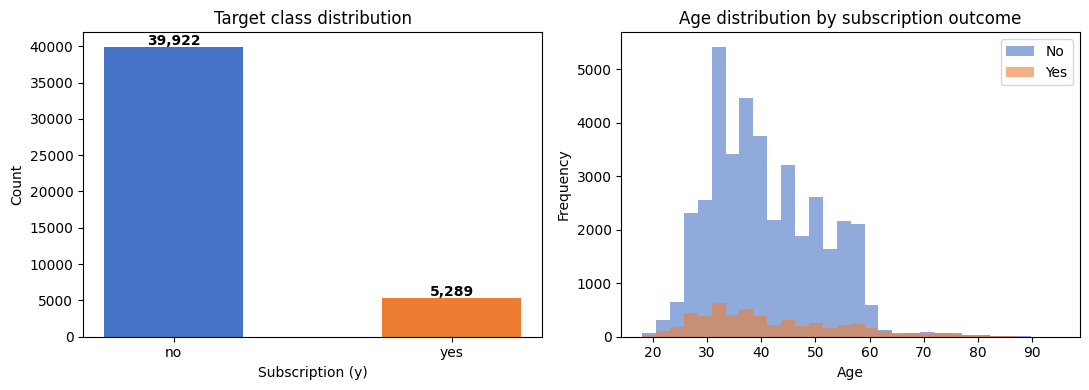

In [ ]:
def run_eda(df: pd.DataFrame) -> None:
    """Print key EDA statistics and display class-distribution plot.

    Args:
        df: Raw DataFrame.
    """
    print("[Dataset shape]", df.shape)
    print("\n[Data types]")
    display(df.dtypes.to_frame("dtype").T)

    print("\n[Target distribution]")
    vc = df["y"].value_counts()
    display(vc.to_frame())
    ratio = vc["no"] / vc["yes"]
    print(f"\nImbalance ratio  no : yes  =  {ratio:.1f} : 1")

    print("\n[Hidden missing values — 'unknown' counts]")
    for col in df.select_dtypes(include="object").columns:
        n = (df[col] == "unknown").sum()
        if n:
            print(f"  {col:12s}: {n:5d}  ({100*n/len(df):.1f}%)")

    print(f"\n[pdays = -1 (never contacted)]: {(df['pdays'] == -1).sum()} rows")

    print("\n[Basic statistics]")
    display(df.describe())

    # ── Class distribution plot ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    counts = df["y"].value_counts()
    axes[0].bar(counts.index, counts.values, color=["#4472C4", "#ED7D31"], width=0.5)
    axes[0].set_title("Target class distribution")
    axes[0].set_xlabel("Subscription (y)")
    axes[0].set_ylabel("Count")
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 300, f"{v:,}", ha="center", fontsize=10, fontweight="bold")

    # Age distribution by class
    df[df["y"] == "no"]["age"].plot.hist(ax=axes[1], alpha=0.6, bins=30, label="No", color="#4472C4")
    df[df["y"] == "yes"]["age"].plot.hist(ax=axes[1], alpha=0.6, bins=30, label="Yes", color="#ED7D31")
    axes[1].set_title("Age distribution by subscription outcome")
    axes[1].set_xlabel("Age")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "eda_overview.png"), dpi=120)
    plt.show()

run_eda(raw_df)

## Step 5 — Feature Engineering

All transformations are applied **before** the train/test split so they are consistent, but **none of them use any target information**, so there is no leakage:

| Change | Reason |
|---|---|
| Drop `duration` | Post-call proxy → severe data leakage |
| `pdays = -1` → `was_previously_contacted` flag + clip to 0 | Sentinel value misleads numeric models |
| `month` → `month_sin` / `month_cos` | Cyclic encoding preserves Jan↔Dec adjacency |
| `contact_missing`, `poutcome_missing` flags | Missingness itself is informative (28% / 82% unknown) |

In [ ]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Domain-informed feature engineering applied before any split.

    Args:
        df: Raw DataFrame.

    Returns:
        Engineered DataFrame ready for splitting.
    """
    df = df.copy()

    # ── Target encoding ───────────────────────────────────────────────────────
    df["y"] = df["y"].map({"yes": 1, "no": 0})

    # ── Drop leaky feature ────────────────────────────────────────────────────
    # duration = call duration in seconds; only known AFTER the call ends.
    # Including it would give the model a direct proxy for the outcome.
    df.drop(columns=["duration"], inplace=True)

    # ── pdays sentinel -1 handling ────────────────────────────────────────────
    # 81.7% of pdays == -1 means "never previously contacted".
    # Passing -1 as a raw numeric is misleading — we split the signal.
    df["was_previously_contacted"] = (df["pdays"] != -1).astype(int)
    df["pdays"] = df["pdays"].clip(lower=0)   # -1 -> 0; real values unchanged

    # ── Cyclic month encoding ─────────────────────────────────────────────────
    # OHE treats Jan and Dec as completely unrelated; sin/cos encoding
    # preserves their adjacency on the circular calendar.
    month_map = {
        "jan": 1, "feb": 2, "mar": 3, "apr": 4,
        "may": 5, "jun": 6, "jul": 7, "aug": 8,
        "sep": 9, "oct": 10, "nov": 11, "dec": 12,
    }
    m = df["month"].str.lower().map(month_map)
    df["month_sin"] = np.sin(2 * np.pi * m / 12)
    df["month_cos"] = np.cos(2 * np.pi * m / 12)
    df.drop(columns=["month"], inplace=True)

    # ── Missingness flags ─────────────────────────────────────────────────────
    # 'unknown' in contact (28.8%) and poutcome (81.7%) is de-facto missing.
    # Adding a binary flag lets the model learn that the absence of info
    # is itself a predictive signal.
    for col in ["contact", "poutcome"]:
        df[f"{col}_missing"] = (df[col] == "unknown").astype(int)

    log.info("Feature engineering done. Shape: %s", df.shape)
    return df

df = engineer_features(raw_df)
print("New features added:",
      [c for c in df.columns if c not in raw_df.columns and c != "y"])
print("Removed features : ['duration', 'month']")
df.head(3)

New features added: ['was_previously_contacted', 'month_sin', 'month_cos', 'contact_missing', 'poutcome_missing']
Removed features : ['duration', 'month']


,age,job,marital,education,default,balance,housing,loan,contact,day,campaign,pdays,previous,poutcome,y,was_previously_contacted,month_sin,month_cos,contact_missing,poutcome_missing
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,1,0,0,unknown,0,0,0.5,-0.866025,1,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,1,0,0,unknown,0,0,0.5,-0.866025,1,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,1,0,0,unknown,0,0,0.5,-0.866025,1,1


## Step 6 — Train / Test Split
The split happens **before** any fitting (scaler, encoder, SMOTE). This is the most important structural decision in the pipeline — it prevents all forms of data leakage.

In [ ]:
X = df.drop(columns=["y"])
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,          # preserve class ratio in both splits
)

# Identify column types from training set only
numeric_cols     = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Train : {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train class balance — No: {(y_train==0).sum():,}  Yes: {(y_train==1).sum():,}")
print(f"Test  class balance — No: {(y_test==0).sum():,}   Yes: {(y_test==1).sum():,}")
print(f"\nNumeric features ({len(numeric_cols)})     : {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Train : 36,168 rows  |  Test: 9,043 rows
Train class balance — No: 31,937  Yes: 4,231
Test  class balance — No: 7,985   Yes: 1,058

Numeric features (11)     : ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'was_previously_contacted', 'month_sin', 'month_cos', 'contact_missing', 'poutcome_missing']
Categorical features (8): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']


## Step 7 — Preprocessor (ColumnTransformer)

- **StandardScaler** on numerics — required by Logistic Regression and the stacking meta-learner. Tree models are scale-invariant so this doesn't hurt them, and keeping one unified preprocessor simplifies the pipeline.
- **OneHotEncoder** `drop='first'` — avoids perfect multicollinearity for LR. `handle_unknown='ignore'` prevents crashes on unseen categories at inference time.
- **Imbalance handling**: `class_weight='balanced'` on all classifiers — mathematically equivalent to oversampling the minority class by weighting each sample's loss contribution by `n_samples / (n_classes × class_count)`.

In [ ]:
def build_preprocessor(
    numeric_cols: List[str],
    categorical_cols: List[str],
) -> ColumnTransformer:
    """Build a ColumnTransformer: StandardScaler + OneHotEncoder.

    Args:
        numeric_cols: Columns to scale.
        categorical_cols: Columns to one-hot encode.

    Returns:
        Unfitted ColumnTransformer (fitted inside each Pipeline).
    """
    numeric_pipe     = Pipeline([("scaler", StandardScaler())])
    categorical_pipe = Pipeline([
        ("ohe", OneHotEncoder(
            drop="first",
            sparse_output=False,
            handle_unknown="ignore",
        ))
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe,     numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )

preprocessor = build_preprocessor(numeric_cols, categorical_cols)
print("Preprocessor built (unfitted). It will be fitted inside each Pipeline.")

Preprocessor built (unfitted). It will be fitted inside each Pipeline.


## Step 8 — Define Model Pipelines

Every model is wrapped in an `sklearn.pipeline.Pipeline` that bundles the preprocessor with the classifier.
This is critical: when `cross_validate` splits data, the preprocessor is **re-fitted on the training fold only** — validation folds are never seen during fitting, eliminating preprocessing leakage entirely.

**Overfitting controls applied to all tree models:**

| Parameter | Value | Why |
|---|---|---|
| `max_depth` | 10 (RF), 4 (GBC) | Prevents trees from growing deep enough to memorise individual training samples |
| `min_samples_leaf` | 5 | Each leaf must represent at least 5 samples — no pure single-sample leaves |
| `max_features` | `'sqrt'` | Only √n features considered per split — adds randomness and reduces variance |
| `subsample` | 0.8 (GBC) | Each tree sees only 80% of rows — stochastic gradient boosting |
| `C=0.5` (LR) | 0.5 | L2 regularisation on logistic regression (lower = more regularised) |
| `n_estimators` | 200 | Reduced from 300 — with proper depth constraints fewer trees are sufficient |

In [ ]:
def build_pipelines(preprocessor: ColumnTransformer) -> Dict[str, Pipeline]:
    """Define one Pipeline per model.

    Ensemble taxonomy:
        - Logistic Regression  : Baseline (linear classifier, not an ensemble)
        - Random Forest        : Bagging  — many trees, bootstrap sampling,
                                 parallel fitting, reduces variance
        - Gradient Boosting    : Boosting — sequential trees, each corrects
                                 the previous residuals, reduces bias
        - Stacking Classifier  : Stacking — meta-learner trained on OOF
                                 predictions from base learners
        - Soft Voting Ensemble : Weighted average of class probabilities

    Overfitting controls applied:
        - max_depth=8 on all Random Forests (unlimited depth memorises training data)
        - min_samples_leaf=5 forces each leaf to represent >= 5 samples
        - max_features='sqrt' limits features per split (adds diversity, reduces variance)
        - n_estimators=200 (reduced from 300 — fewer trees + regularisation = less overfit)
        - GBC subsample=0.8 + max_depth=4 already provide regularisation via shrinkage

    Why class_weight='balanced'?
        Scales each sample's loss by n / (k * class_count) — effectively
        overweights minority-class samples during fitting without resampling.

    Args:
        preprocessor: Unfitted ColumnTransformer (deep-copied per pipeline).

    Returns:
        Dict of model name -> unfitted Pipeline.
    """

    def prep():
        return copy.deepcopy(preprocessor)

    # ── Base classifiers ──────────────────────────────────────────────────────
    lr = LogisticRegression(
        max_iter=1000, class_weight="balanced",
        random_state=RANDOM_SEED, solver="lbfgs",
        C=0.5,   # L2 regularisation strength (lower = more regularised)
    )

    # RF regularisation: max_depth + min_samples_leaf prevent deep memorisation
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,             # was None (unlimited) -> key overfitting fix
        min_samples_leaf=5,       # each leaf must cover >= 5 samples
        max_features="sqrt",      # consider sqrt(n_features) per split
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    gb = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,              # shallow trees = weaker learners = less overfit
        subsample=0.8,            # stochastic gradient boosting (row sampling)
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
    )

    # ── Stacking Classifier ───────────────────────────────────────────────────
    # Same regularised base estimators — important: use regularised versions here too
    stacking_clf = StackingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(
                n_estimators=150, max_depth=10, min_samples_leaf=5,
                max_features="sqrt", class_weight="balanced_subsample",
                random_state=RANDOM_SEED, n_jobs=-1)),
            ("gb", GradientBoostingClassifier(
                n_estimators=150, learning_rate=0.05,
                max_depth=4, subsample=0.8, min_samples_leaf=5,
                random_state=RANDOM_SEED)),
        ],
        final_estimator=LogisticRegression(
            max_iter=500, C=0.5, class_weight="balanced", random_state=RANDOM_SEED
        ),
        cv=5,
        passthrough=False,
        n_jobs=-1,
    )

    # ── Soft Voting Ensemble ──────────────────────────────────────────────────
    # All base estimators use the same regularisation as above
    voting_clf = VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(
                max_iter=1000, C=0.5, class_weight="balanced",
                random_state=RANDOM_SEED)),
            ("rf", RandomForestClassifier(
                n_estimators=200, max_depth=10, min_samples_leaf=5,
                max_features="sqrt", class_weight="balanced_subsample",
                random_state=RANDOM_SEED, n_jobs=-1)),
            ("gb", GradientBoostingClassifier(
                n_estimators=200, learning_rate=0.05, max_depth=4,
                subsample=0.8, min_samples_leaf=5, random_state=RANDOM_SEED)),
        ],
        voting="soft",
        weights=[1, 2, 3],
    )

    return {
        "Logistic Regression (baseline)": Pipeline([("prep", prep()), ("clf", lr)]),
        "Random Forest (Bagging)":         Pipeline([("prep", prep()), ("clf", rf)]),
        "Gradient Boosting (Boosting)":    Pipeline([("prep", prep()), ("clf", gb)]),
        "Stacking Classifier":             Pipeline([("prep", prep()), ("clf", stacking_clf)]),
        "Soft Voting Ensemble":            Pipeline([("prep", prep()), ("clf", voting_clf)]),
    }

pipelines = build_pipelines(preprocessor)
print("Pipelines defined:")
for name in pipelines:
    print(f"  * {name}")


Pipelines defined:
  * Logistic Regression (baseline)
  * Random Forest (Bagging)
  * Gradient Boosting (Boosting)
  * Stacking Classifier
  * Soft Voting Ensemble


## Step 9 — Hyperparameter Tuning (Gradient Boosting)

**Why RandomizedSearchCV over GridSearchCV?**  
Grid search is O(n_params^k) — the search space explodes with more parameters. Randomized search samples `n_iter` random combinations, which is computationally cheaper and empirically finds near-optimal configs when some parameters have low sensitivity.

**Scoring metric**: `average_precision` (PR-AUC) — the most informative scalar metric for imbalanced datasets because it is not inflated by the large number of true negatives (unlike ROC-AUC).

> ⏱️ **This cell takes ~5–10 minutes on Colab.** Grab a coffee.

In [ ]:
def tune_gradient_boosting(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    preprocessor: ColumnTransformer,
) -> Pipeline:
    """Tune GradientBoostingClassifier via RandomizedSearchCV.

    The search runs inside a Pipeline so that the preprocessor is
    re-fitted within each CV fold — no leakage from the scaler or OHE.

    Args:
        X_train: Raw training features.
        y_train: Training labels.
        preprocessor: Unfitted ColumnTransformer.

    Returns:
        Pipeline with best found hyperparameters, fitted on full X_train.
    """
    log.info("Tuning GradientBoostingClassifier via RandomizedSearchCV ...")

    pipe = Pipeline([
        ("prep", copy.deepcopy(preprocessor)),
        ("clf",  GradientBoostingClassifier(random_state=RANDOM_SEED)),
    ])

    param_dist = {
        "clf__n_estimators":      [100, 150, 200, 300],
        "clf__learning_rate":     [0.01, 0.05, 0.1, 0.15],
        "clf__max_depth":         [3, 4, 5],
        "clf__subsample":         [0.6, 0.7, 0.8, 0.9],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf":  [1, 3, 5, 10],
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=20,
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    search.fit(X_train, y_train)

    print(f"\nBest GBC params : {search.best_params_}")
    print(f"Best CV PR-AUC  : {search.best_score_:.4f}")
    return search.best_estimator_

best_gb_pipe = tune_gradient_boosting(X_train, y_train, preprocessor)

# Replace default GB pipeline with tuned version
pipelines["Gradient Boosting [Tuned]"] = best_gb_pipe
pipelines.pop("Gradient Boosting (Boosting)", None)
print("\nUpdated pipeline set:")
for name in pipelines:
    print(f"  • {name}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best GBC params : {'clf__subsample': 0.8, 'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 10, 'clf__max_depth': 5, 'clf__learning_rate': 0.05}
Best CV PR-AUC  : 0.4457

Updated pipeline set:
  • Logistic Regression (baseline)
  • Random Forest (Bagging)
  • Stacking Classifier
  • Soft Voting Ensemble
  • Gradient Boosting [Tuned]


## Step 10 — Leak-Free Cross-Validation

Because preprocessing is **inside** each Pipeline, `cross_validate` re-fits the scaler and OHE on each training fold — the validation fold is never seen during fitting. This is the correct way to run CV with preprocessing steps.

The three metrics reported:
- **PR-AUC** (`average_precision`) — primary metric for imbalanced classification
- **ROC-AUC** — overall discrimination ability
- **F1 (macro)** — harmonic mean of precision and recall, averaged across classes

In [ ]:
def cross_validate_models(
    pipelines: Dict[str, Pipeline],
    X_train: pd.DataFrame,
    y_train: pd.Series,
) -> pd.DataFrame:
    """Run stratified k-fold CV on each pipeline (leak-free).

    Args:
        pipelines: Dict of name -> unfitted Pipeline.
        X_train: Raw training features.
        y_train: Training labels.

    Returns:
        DataFrame with mean +/- std for each metric per model.
    """
    log.info("Running %d-fold stratified cross-validation ...", CV_FOLDS)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    scoring = {
        "roc_auc":           "roc_auc",
        "average_precision": "average_precision",
        "f1_macro":          "f1_macro",
    }

    rows = []
    for name, pipe in pipelines.items():
        log.info("  CV -> %s", name)
        res = cross_validate(
            pipe, X_train, y_train,
            cv=cv, scoring=scoring, n_jobs=-1,
        )
        rows.append({
            "Model":       name,
            "ROC-AUC":     f"{res['test_roc_auc'].mean():.4f} +/- {res['test_roc_auc'].std():.4f}",
            "PR-AUC":      f"{res['test_average_precision'].mean():.4f} +/- {res['test_average_precision'].std():.4f}",
            "F1 (macro)":  f"{res['test_f1_macro'].mean():.4f} +/- {res['test_f1_macro'].std():.4f}",
        })

    cv_df = pd.DataFrame(rows).set_index("Model")
    return cv_df

cv_df = cross_validate_models(pipelines, X_train, y_train)
print("\n5-Fold Cross-Validation Results (Training Set):")
display(cv_df)


5-Fold Cross-Validation Results (Training Set):


,ROC-AUC,PR-AUC,F1 (macro)
Model,,,
Logistic Regression (baseline),0.7450 +/- 0.0034,0.3656 +/- 0.0074,0.5745 +/- 0.0033
Random Forest (Bagging),0.7916 +/- 0.0033,0.4317 +/- 0.0119,0.6688 +/- 0.0072
Stacking Classifier,0.7948 +/- 0.0034,0.4416 +/- 0.0142,0.6599 +/- 0.0090
Soft Voting Ensemble,0.7917 +/- 0.0022,0.4411 +/- 0.0134,0.6786 +/- 0.0072
Gradient Boosting [Tuned],0.7986 +/- 0.0038,0.4461 +/- 0.0141,0.6408 +/- 0.0078


### Step 11 — Train All Models on Full Training Set

In [ ]:
def train_models(
    pipelines: Dict[str, Pipeline],
    X_train: pd.DataFrame,
    y_train: pd.Series,
) -> Dict[str, Pipeline]:
    """Fit every pipeline on the full training set.

    Args:
        pipelines: Dict of name -> unfitted Pipeline.
        X_train: Training features.
        y_train: Training labels.

    Returns:
        Dict of name -> fitted Pipeline.
    """
    fitted = {}
    for name, pipe in pipelines.items():
        log.info("Training: %s ...", name)
        pipe.fit(X_train, y_train)
        fitted[name] = pipe
        print(f"  [DONE] {name}")
    return fitted

fitted_models = train_models(pipelines, X_train, y_train)
print("\nAll models trained successfully.")

  [DONE] Logistic Regression (baseline)
  [DONE] Random Forest (Bagging)
  [DONE] Stacking Classifier
  [DONE] Soft Voting Ensemble
  [DONE] Gradient Boosting [Tuned]

All models trained successfully.


## Step 12 — Evaluation (Train vs. Test — Overfitting Check)

Comparing train and test metrics is the primary tool for diagnosing overfitting:
- **Train score >> Test score** → model is memorising the training data (overfitting)
- **Both similar and high** → good generalisation

**Primary metric**: PR-AUC (`average_precision_score`) — not inflated by true negatives.

In [ ]:
def compute_metrics(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    split_label: str = "test",
) -> Dict[str, float]:
    """Compute full suite of classification metrics.

    Args:
        model: Fitted Pipeline.
        X: Feature matrix.
        y: True labels.
        split_label: 'train' or 'test'.

    Returns:
        Dict of metric-name -> value.
    """
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        "split":     split_label,
        "accuracy":  accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall":    recall_score(y, y_pred, zero_division=0),
        "f1":        f1_score(y, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y, y_proba),
        "pr_auc":    average_precision_score(y, y_proba),
    }


def evaluate_models(
    fitted_models: Dict[str, Pipeline],
    X_train, y_train,
    X_test, y_test,
) -> pd.DataFrame:
    """Evaluate all models — train vs. test comparison for overfitting check.

    Args:
        fitted_models: Dict of name -> fitted Pipeline.
        X_train / y_train: Training data.
        X_test  / y_test : Test data.

    Returns:
        DataFrame with test metrics for all models.
    """
    test_rows = []

    for name, model in fitted_models.items():
        train_m = compute_metrics(model, X_train, y_train, "train")
        test_m  = compute_metrics(model, X_test,  y_test,  "test")

        print(f"\n{'='*62}")
        print(f"  {name}")
        print(f"{'='*62}")
        print(f"  {'Metric':<12}  {'Train':>8}  {'Test':>8}  {'Gap':>8}")
        print(f"  {'-'*46}")
        for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
            gap  = train_m[metric] - test_m[metric]
            flag = "  <- high gap" if gap > 0.08 else ""
            print(f"  {metric:<12}  {train_m[metric]:>8.4f}  {test_m[metric]:>8.4f}  {gap:>+8.4f}{flag}")

        y_pred = model.predict(X_test)
        print(f"\n  Classification Report (Test):")
        print(classification_report(y_test, y_pred,
                                    target_names=["No (0)", "Yes (1)"],
                                    digits=4))

        test_m["model"] = name
        test_rows.append(test_m)

    return pd.DataFrame(test_rows).set_index("model")


metrics_df = evaluate_models(fitted_models, X_train, y_train, X_test, y_test)


  Logistic Regression (baseline)
  Metric           Train      Test       Gap
  ----------------------------------------------
  accuracy        0.7032    0.6986   +0.0047
  precision       0.2318    0.2301   +0.0017
  recall          0.6644    0.6720   -0.0076
  f1              0.3437    0.3428   +0.0009
  roc_auc         0.7486    0.7551   -0.0064
  pr_auc          0.3686    0.3665   +0.0021

  Classification Report (Test):
              precision    recall  f1-score   support

      No (0)     0.9417    0.7021    0.8044      7985
     Yes (1)     0.2301    0.6720    0.3428      1058

    accuracy                         0.6986      9043
   macro avg     0.5859    0.6870    0.5736      9043
weighted avg     0.8585    0.6986    0.7504      9043


  Random Forest (Bagging)
  Metric           Train      Test       Gap
  ----------------------------------------------
  accuracy        0.8320    0.8200   +0.0121
  precision       0.3751    0.3494   +0.0258
  recall          0.6547    0.6

## Step 13 — Visualisations

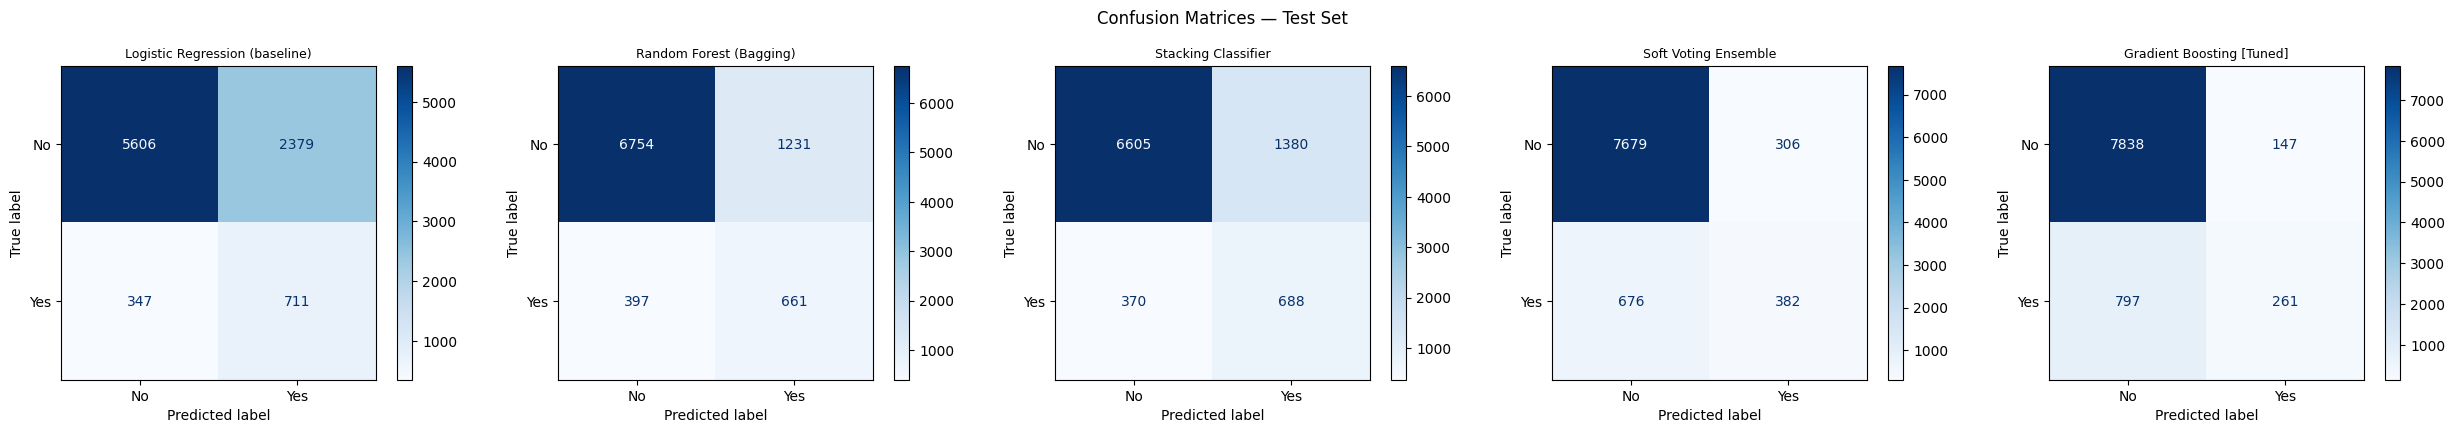

In [ ]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
n = len(fitted_models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, fitted_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["No", "Yes"],
        cmap="Blues", ax=ax,
    )
    ax.set_title(name, fontsize=9)

plt.suptitle("Confusion Matrices — Test Set", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "confusion_matrices.png"), dpi=120, bbox_inches="tight")
plt.show()

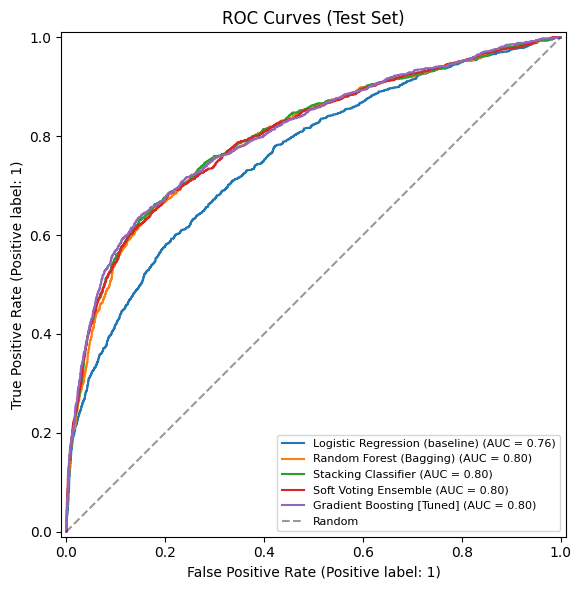

In [ ]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_title("ROC Curves (Test Set)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "roc_curves.png"), dpi=120)
plt.show()

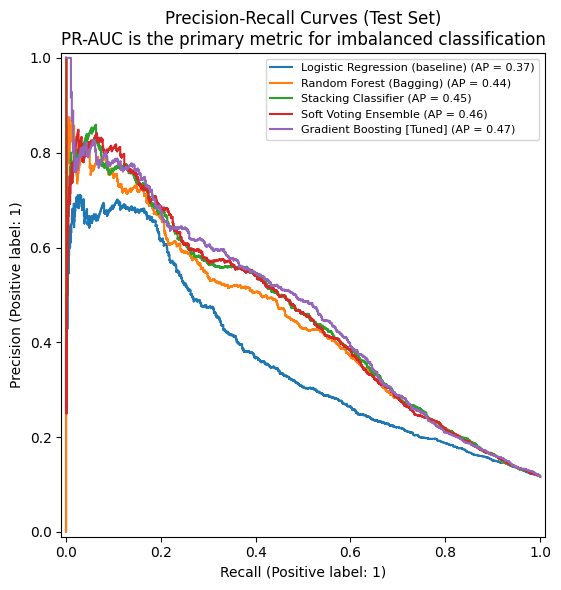

In [ ]:
# ── Precision-Recall Curves ───────────────────────────────────────────────────
# This is the PRIMARY evaluation plot for imbalanced datasets.
# PR-AUC is not inflated by the large number of true negatives.
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in fitted_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("Precision-Recall Curves (Test Set)\nPR-AUC is the primary metric for imbalanced classification")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "pr_curves.png"), dpi=120)
plt.show()

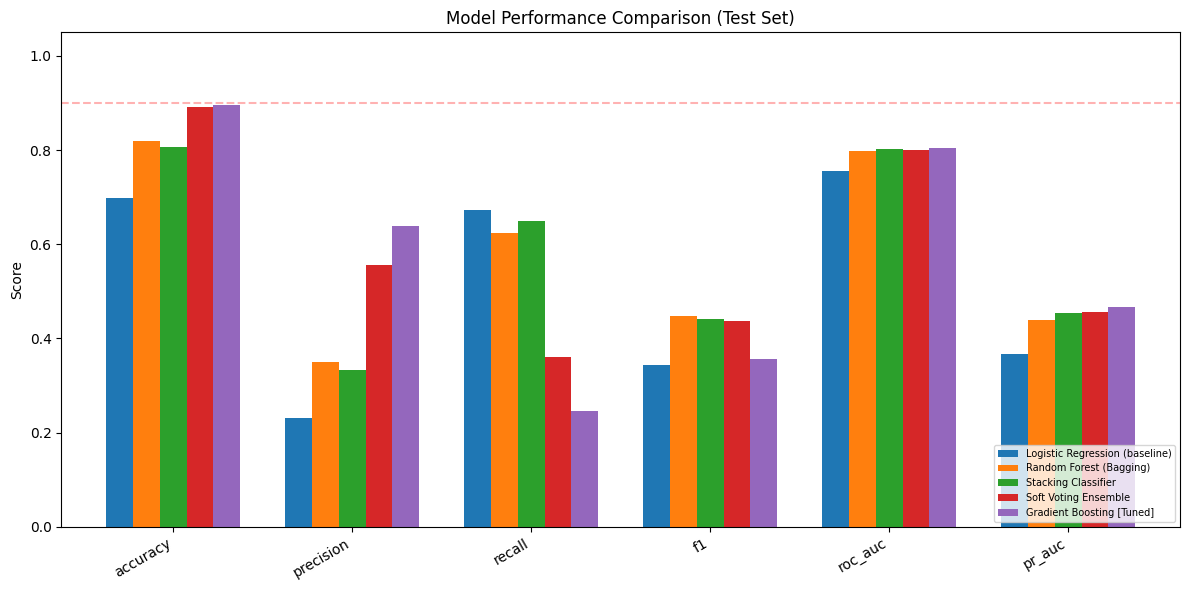

In [ ]:
# ── Model Performance Comparison Bar Chart ────────────────────────────────────
cols_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
ax = metrics_df[cols_to_plot].T.plot(kind="bar", figsize=(12, 6), width=0.75)
ax.set_title("Model Performance Comparison (Test Set)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(cols_to_plot, rotation=30, ha="right")
ax.legend(loc="lower right", fontsize=7)
ax.axhline(y=0.9, color="red", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "metric_comparison.png"), dpi=120)
plt.show()

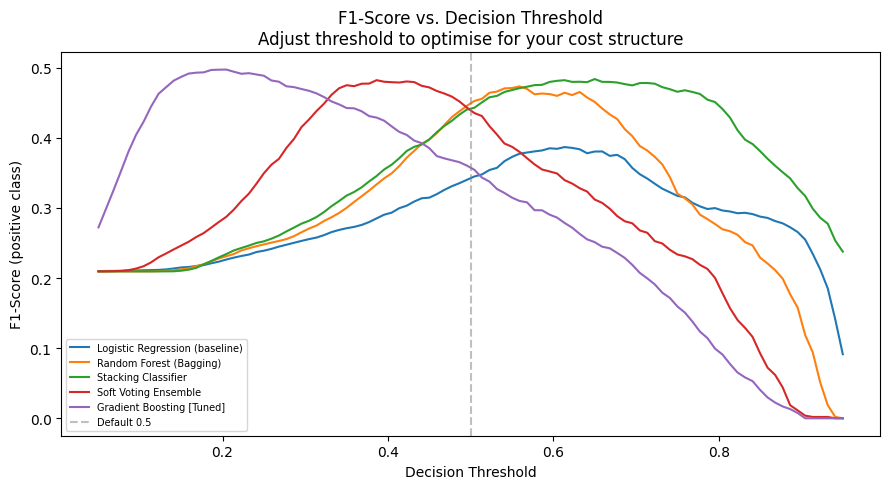

In [ ]:
# ── Threshold Analysis ────────────────────────────────────────────────────────
# Business context: In telemarketing, the cost of a false negative
# (missing a subscriber = lost revenue) differs from a false positive
# (calling a non-subscriber = wasted agent time). This plot lets a
# stakeholder pick the threshold that matches their cost structure.
thresholds_grid = np.linspace(0.05, 0.95, 100)
fig, ax = plt.subplots(figsize=(9, 5))

for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    f1s = [
        f1_score(y_test, (y_proba >= t).astype(int), zero_division=0)
        for t in thresholds_grid
    ]
    ax.plot(thresholds_grid, f1s, label=name)

ax.axvline(0.5, linestyle="--", color="gray", alpha=0.5, label="Default 0.5")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("F1-Score (positive class)")
ax.set_title("F1-Score vs. Decision Threshold\nAdjust threshold to optimise for your cost structure")
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "threshold_analysis.png"), dpi=120)
plt.show()

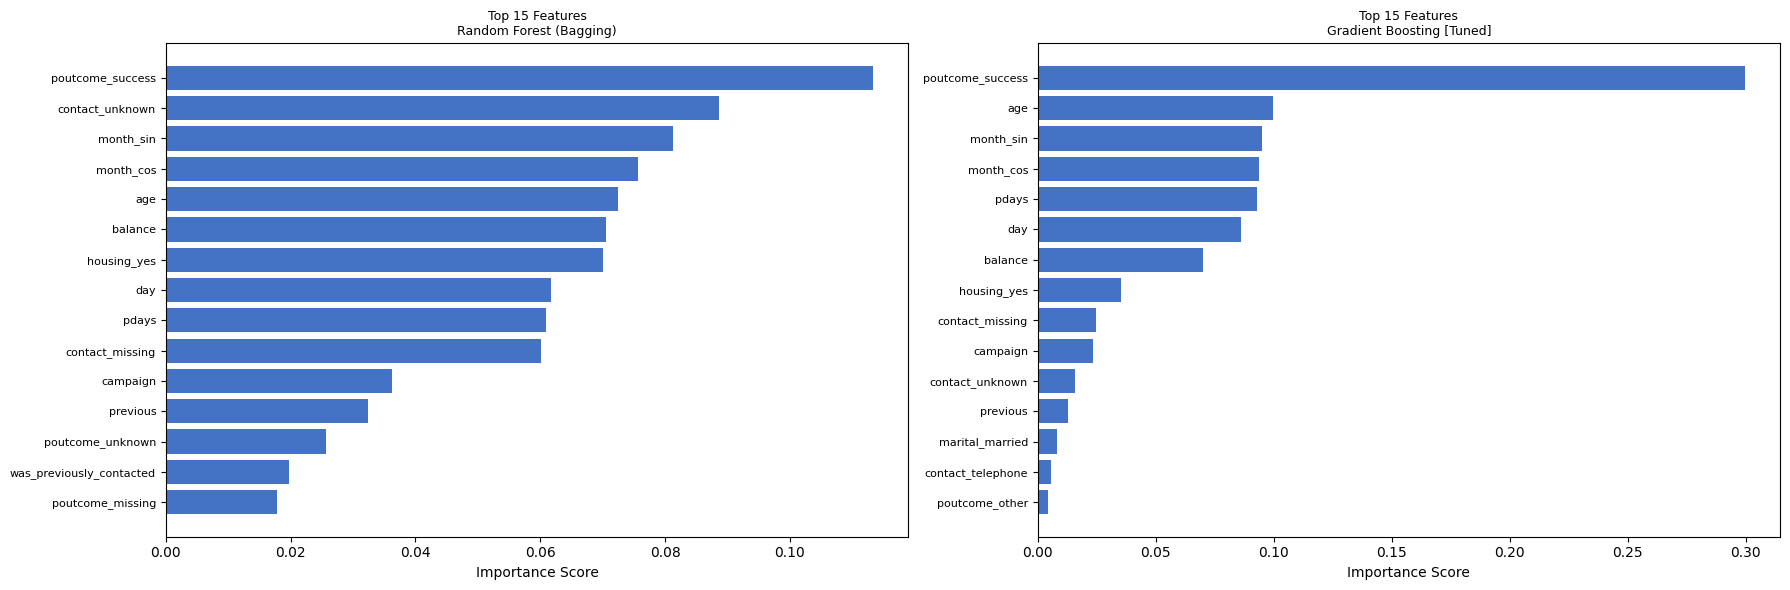

In [ ]:
# ── Feature Importances (tree models only) ────────────────────────────────────
# Temporarily fit the preprocessor to extract feature names after OHE
tmp_prep = copy.deepcopy(preprocessor)
tmp_prep.fit(X_train)
try:
    ohe_names  = tmp_prep.named_transformers_["cat"]["ohe"].get_feature_names_out(categorical_cols).tolist()
    feat_names = numeric_cols + ohe_names
except Exception:
    feat_names = [f"f{i}" for i in range(len(numeric_cols) + 50)]

tree_models = {
    name: model for name, model in fitted_models.items()
    if hasattr(model.named_steps["clf"], "feature_importances_")
}

if tree_models:
    fig, axes = plt.subplots(1, len(tree_models), figsize=(9 * len(tree_models), 6))
    if len(tree_models) == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, tree_models.items()):
        clf = model.named_steps["clf"]
        importances = clf.feature_importances_
        top_n = 15
        indices = np.argsort(importances)[::-1][:top_n]
        ax.barh(range(top_n), importances[indices][::-1], color="#4472C4")
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(
            [feat_names[i] if i < len(feat_names) else f"f{i}" for i in indices[::-1]],
            fontsize=8,
        )
        ax.set_xlabel("Importance Score")
        ax.set_title(f"Top {top_n} Features\n{name}", fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "feature_importances.png"), dpi=120)
    plt.show()

## Step 14 — Final Summary

In [ ]:
display_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
ranked = metrics_df[display_cols].sort_values("pr_auc", ascending=False)

print("=" * 70)
print("  FINAL SUMMARY — TEST SET PERFORMANCE (ranked by PR-AUC)")
print("=" * 70)
display(ranked.round(4).style.highlight_max(axis=0, color="lightgreen")
                              .highlight_min(axis=0, color="#ffcccc"))

print("\n" + "=" * 70)
print("  5-FOLD CROSS-VALIDATION RESULTS (Training Set)")
print("=" * 70)
display(cv_df)

best = ranked.index[0]
print(f"\n  Best model by PR-AUC : {best}")
print(f"  PR-AUC  = {ranked.loc[best, 'pr_auc']:.4f}")
print(f"  ROC-AUC = {ranked.loc[best, 'roc_auc']:.4f}")
print(f"  F1      = {ranked.loc[best, 'f1']:.4f}")
print("=" * 70)
print(f"\nAll plots saved to '{PLOTS_DIR}/' folder.")

  FINAL SUMMARY — TEST SET PERFORMANCE (ranked by PR-AUC)


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Gradient Boosting [Tuned],0.895600,0.639700,0.246700,0.356100,0.804000,0.466000
Soft Voting Ensemble,0.891400,0.555200,0.361100,0.437600,0.800500,0.455600
Stacking Classifier,0.806500,0.332700,0.650300,0.440200,0.802200,0.454400
Random Forest (Bagging),0.820000,0.349400,0.624800,0.448100,0.798600,0.440000
Logistic Regression (baseline),0.698600,0.230100,0.672000,0.342800,0.755100,0.366500



  5-FOLD CROSS-VALIDATION RESULTS (Training Set)


,ROC-AUC,PR-AUC,F1 (macro)
Model,,,
Logistic Regression (baseline),0.7450 +/- 0.0034,0.3656 +/- 0.0074,0.5745 +/- 0.0033
Random Forest (Bagging),0.7916 +/- 0.0033,0.4317 +/- 0.0119,0.6688 +/- 0.0072
Stacking Classifier,0.7948 +/- 0.0034,0.4416 +/- 0.0142,0.6599 +/- 0.0090
Soft Voting Ensemble,0.7917 +/- 0.0022,0.4411 +/- 0.0134,0.6786 +/- 0.0072
Gradient Boosting [Tuned],0.7986 +/- 0.0038,0.4461 +/- 0.0141,0.6408 +/- 0.0078



  Best model by PR-AUC : Gradient Boosting [Tuned]
  PR-AUC  = 0.4660
  ROC-AUC = 0.8040
  F1      = 0.3561

All plots saved to 'plots/' folder.
